In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt

from srm import catalog
from srm.downscaling_utils import interpolate_fine_to_coarse_grid
from srm.utils import open_icechunk

In [2]:
import os

import frisky
from distributed import Client

os.environ["FRISKY_SUMMARY"] = "off"

client = frisky.hijack(Client(n_workers=16))
client

/opt/coiled/env/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 34267 instead
  warnings.warn(


<frisky.Client: scheduler="127.0.0.1:36645" id="client-0">

# Load data

In [3]:
path_qaqc = "/scratch/synced/qa_plots/disagg_checks/"
path_output = "s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/output/production/CESM2-WACCM-ERA5-global.icechunk"
branch = "v0.12.0"

var = "pr"
ssp_ens = "003"
g6_ens = "003"
hist_ens = "r3i1p1f1"

In [4]:
path_output = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
path_qaqc = "/scratch/synced/qa_plots/disagg_checks/"
branch = "v0.11.1"
coarse_debiased_ssp = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/ssp245/" + var + "/" + ssp_ens,
)[var]

In [4]:
# Coarse debiased data

coarse_debiased_ssp = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/ssp245/" + var + "/" + ssp_ens,
)[var]

coarse_debiased_historical = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/historical/" + var + "/" + hist_ens,
)[var]

coarse_debiased_g6 = open_icechunk(
    path=path_output,
    branch=branch,
    group="debiased_coarse/g6_1p5k/" + var + "/" + g6_ens,
)[var]

In [6]:
obs_cache_path = (
    "s3://carbonplan-scratch/srm/bcsd-cache/production/CESM2-WACCM-ERA5-global.icechunk"
)
obs_branch = "v0.11.1"  # scratch/intermediate artifacts always live on "main", per ArtifactCache

coarse_obs = (
    open_icechunk(
        path=obs_cache_path,
        branch=obs_branch,
        group="obs/" + var,
    )[var]
)

In [5]:
fine_obs=catalog.get('ERA5').to_xarray()[var]

In [6]:
# Downscaled, debiased data
ds_debiased_ssp = open_icechunk(
    path=path_output,
    branch=branch,
    group="ssp245/" + var + "/" + ssp_ens,
)[var]

ds_debiased_historical = open_icechunk(
    path=path_output,
    branch=branch,
    group="historical/" + var + "/" + hist_ens,
)[var]

ds_debiased_g6 = open_icechunk(
    path=path_output,
    branch=branch,
    group="g6_1p5k/" + var + "/" + g6_ens,
)[var]

In [7]:
# Raw data
raw_data = catalog.get("CESM2-WACCM").to_xarray()
raw_ssp = raw_data["ssp245"][var].sel(ensemble_member=ssp_ens)
raw_historical = raw_data["historical"][var].sel(ensemble_member=hist_ens)
raw_g6 = raw_data["g6_1p5k"][var].sel(ensemble_member=g6_ens)

# Calculate max plausible value per lat and day of year

In [9]:
# The maximum solar radiation on a given day of year for any gridcell is the same across longitudes

max_value_obs = coarse_obs.max(dim='lon').groupby('time.dayofyear').max(dim='time').load()

In [15]:
max_value_fine_obs = fine_obs.max(dim='lon').groupby('time.dayofyear').max(dim='time').load()

In [16]:
# Note this doesn't need to pull the 'right' ensemble member
max_value_gcm = raw_historical[1:,:,:].max(dim='lon').groupby('time.dayofyear').max(dim='time').load()

In [17]:
max_value_strict = max_value_obs.where(max_value_obs>max_value_gcm, max_value_gcm)

NameError: name 'max_value_obs' is not defined

Text(0.5, 1.0, '')

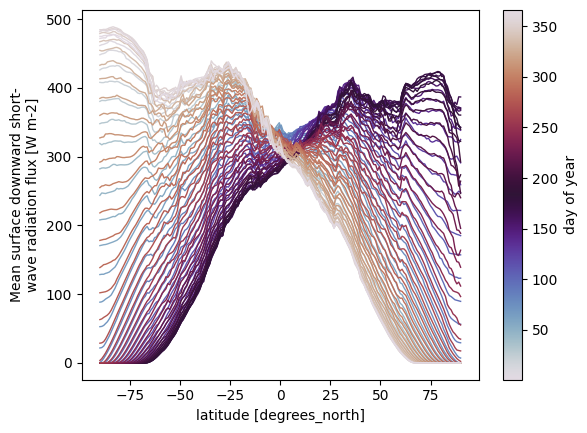

In [12]:
import matplotlib as mpl
import matplotlib.pyplot as plt

cmap = plt.get_cmap("twilight")  # cyclic: doy 1 and 366 are seasonally adjacent
norm = mpl.colors.Normalize(vmin=1, vmax=366)

fig, ax = plt.subplots()
for doy in max_value_obs["dayofyear"].values[::5]:
    max_value_obs.sel(dayofyear=doy).plot(ax=ax, color=cmap(norm(doy)), add_legend=False, linewidth=1)

fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="day of year")
ax.set_title("")

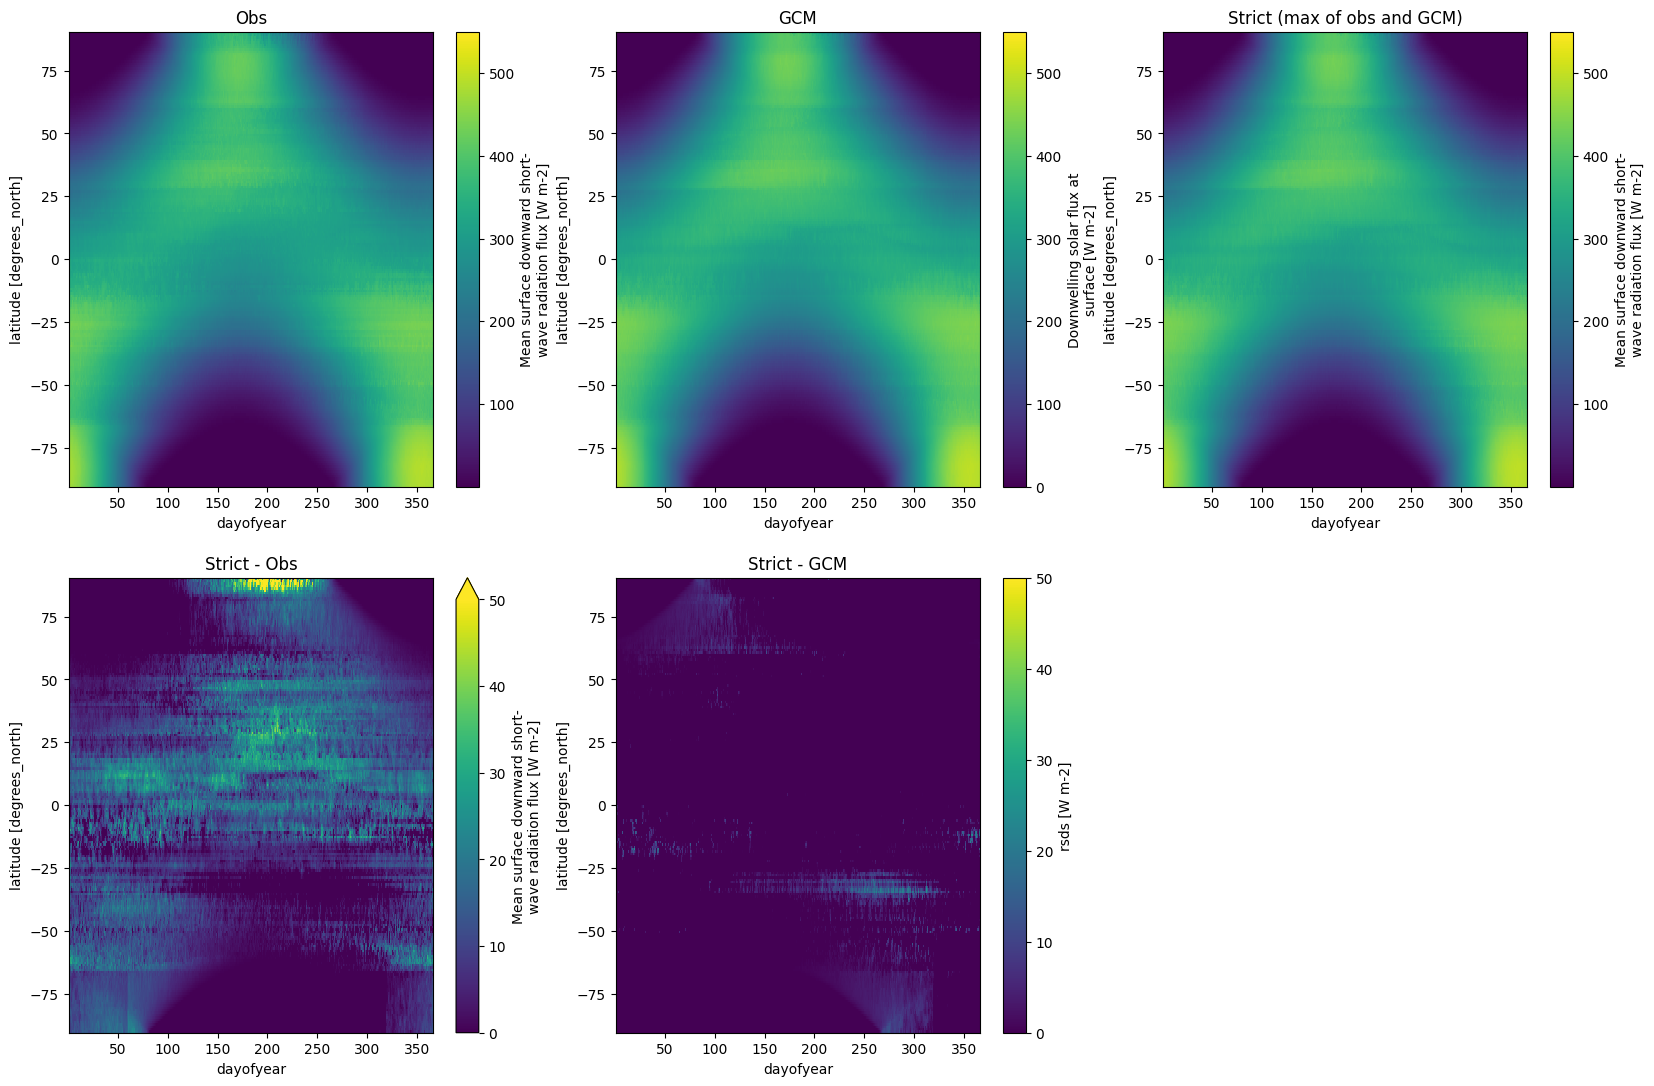

In [13]:
fig, axes=plt.subplots(ncols=3, nrows=2, figsize=(20,13))
(max_value_obs).transpose().plot(ax=axes[0,0], vmax=550)
axes[0,0].set_title('Obs')
(max_value_gcm).transpose().plot(ax=axes[0,1], vmax=550)
axes[0,1].set_title('GCM')
(max_value_strict).transpose().plot(ax=axes[0,2], vmax=550)
axes[0,2].set_title('Strict (max of obs and GCM)')
(max_value_strict - max_value_obs).transpose().plot(ax=axes[1,0], vmax=50)
axes[1,0].set_title('Strict - Obs')
(max_value_strict - max_value_gcm).transpose().plot(ax=axes[1,1], vmax=50)
axes[1,1].set_title('Strict - GCM')
axes[1,2].set_visible(False)

In [86]:
def calculate_frac_over_max(da, max_value=max_value_strict):
    max_aligned = max_value.sel(dayofyear=da["time.dayofyear"])  # .sel on max_value_obs, not da
    frac_over_max = (da > max_aligned).mean(dim="time")  # reduce over time, not dayofyear
    return frac_over_max

In [15]:
def calculate_amount_over_max(da, max_value=max_value_strict):
    max_aligned = max_value.sel(dayofyear=da["time.dayofyear"])  # .sel on max_value_obs, not da
    amount_over_max = (da - max_aligned).max(dim="time")  # reduce over time, not dayofyear
    return amount_over_max

# Run checks!

In [87]:
frac_over_max_ds_ssp=calculate_frac_over_max(da=(ds_debiased_ssp.where(~(ds_debiased_ssp['time.month'].isin([1,12])))), 
                                             max_value=max_value_fine_obs).load()

In [108]:
import flox

In [111]:
val_over_max_ds_ssp=calculate_amount_over_max(da=(ds_debiased_ssp.where(~(ds_debiased_ssp['time.month'].isin([1,12])))), 
                                             max_value=max_value_fine_obs).load()

(0.0, 14.5)

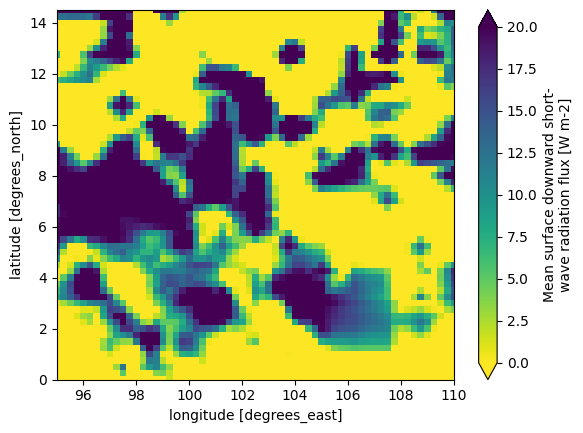

In [118]:
val_over_max_ds_ssp.plot(vmax=20,vmin=0,cmap=plt.cm.viridis_r)
plt.xlim([95,110])
plt.ylim([0,14.5])

In [ ]:
frac_over_max_raw_ssp=calculate_frac_over_max(da=raw_ssp[1:,:,:], 
                                         max_value=max_value_strict).load()

In [17]:
frac_over_max_raw_hist=calculate_frac_over_max(da=raw_historical[1:,:,:],
                                              max_value=max_value_strict).load()

In [18]:
frac_over_max_raw_g6=calculate_frac_over_max(da=raw_g6[1:,:,:],
                                            max_value=max_value_strict).load()

In [19]:
# This will always be 0
frac_over_max_check=calculate_frac_over_max(da=coarse_obs, max_value=max_value_strict).load()

0
945
2000


Text(0.5, 1.0, 'SSP')

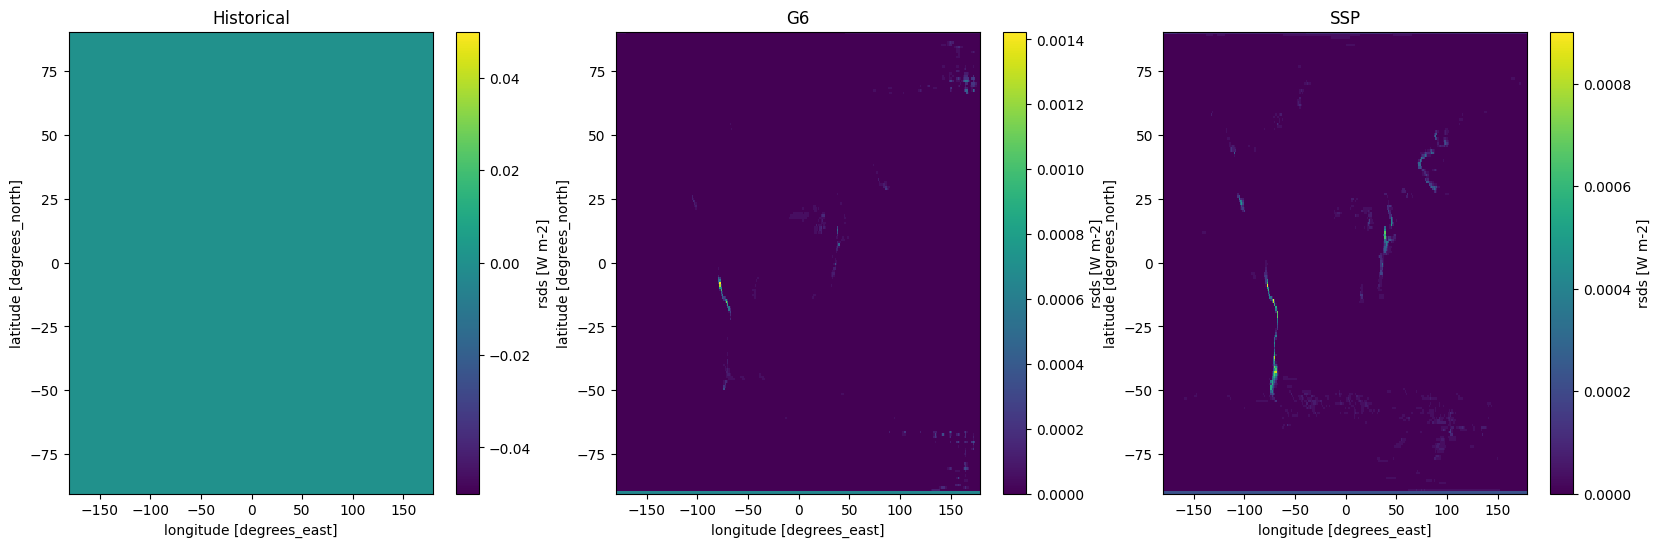

In [20]:
fig, axes=plt.subplots(ncols=3, figsize=(20,6))
frac_over_max_raw_hist.plot(ax=axes[0])
print((frac_over_max_raw_hist>0).sum().values)
axes[0].set_title('Historical')
frac_over_max_raw_g6.plot(ax=axes[1])
print((frac_over_max_raw_g6>0).sum().values)
axes[1].set_title('G6')
frac_over_max_raw_ssp.plot(ax=axes[2])
print((frac_over_max_raw_ssp>0).sum().values)
axes[2].set_title('SSP')

In [21]:
frac_over_max_cd_hist=calculate_frac_over_max(da=coarse_debiased_historical.where(~coarse_debiased_historical['time.month'].isin([1,12])), 
                                         max_value=max_value_strict).load()

frac_over_max_cd_g6=calculate_frac_over_max(da=coarse_debiased_g6.where(~coarse_debiased_g6['time.month'].isin([1,12])), 
                                         max_value=max_value_strict).load()

frac_over_max_cd_ssp=calculate_frac_over_max(da=coarse_debiased_ssp.where(~coarse_debiased_ssp['time.month'].isin([1,12])), 
                                         max_value=max_value_strict).load()

In [22]:
amount_over_max_cd_ssp=calculate_amount_over_max(da=coarse_debiased_ssp.where(~coarse_debiased_ssp['time.month'].isin([1,12])), 
                                         max_value=max_value_strict).load()

In [23]:
frac_over_max_cd_hist=calculate_frac_over_max(da=coarse_debiased_historical,
                                         max_value=max_value_strict).load()

frac_over_max_cd_g6=calculate_frac_over_max(da=coarse_debiased_g6,
                                         max_value=max_value_strict).load()

frac_over_max_cd_ssp=calculate_frac_over_max(da=coarse_debiased_ssp,
                                         max_value=max_value_strict).load()

(10.0, 25.0)

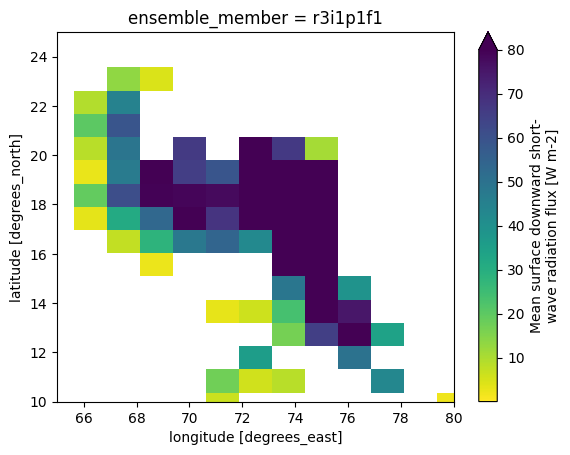

In [99]:
amount_over_max_cd_ssp.where(amount_over_max_cd_ssp>0).plot(vmax=80, cmap=plt.cm.viridis_r)
plt.xlim([65,80])
plt.ylim([10,25])

Text(0.5, 1.0, 'SSP')

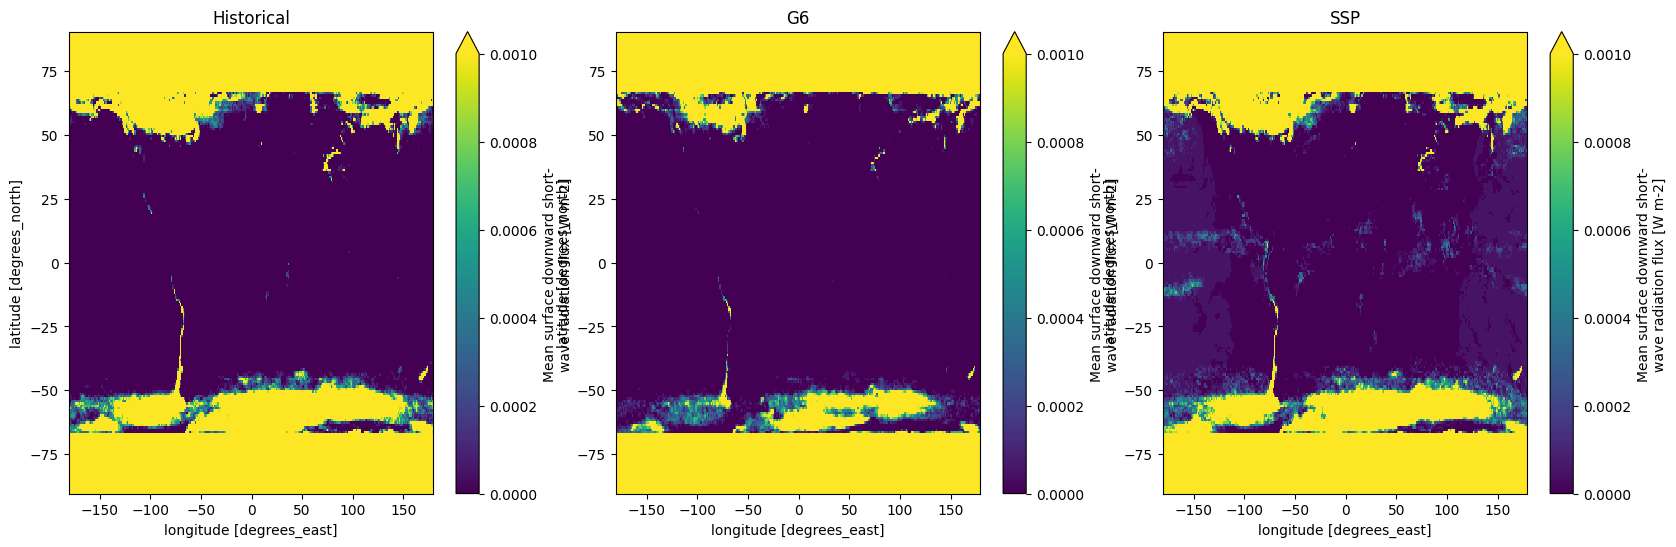

In [25]:
fig, axes=plt.subplots(ncols=3, figsize=(20,6))
frac_over_max_cd_hist.plot(vmax=0.001, ax=axes[0])
axes[0].set_title('Historical')
frac_over_max_cd_g6.plot(vmax=0.001, ax=axes[1])
axes[1].set_title('G6')
frac_over_max_cd_ssp.plot(vmax=0.001, ax=axes[2])
axes[2].set_title('SSP')

Text(0.5, 1.0, 'SSP')

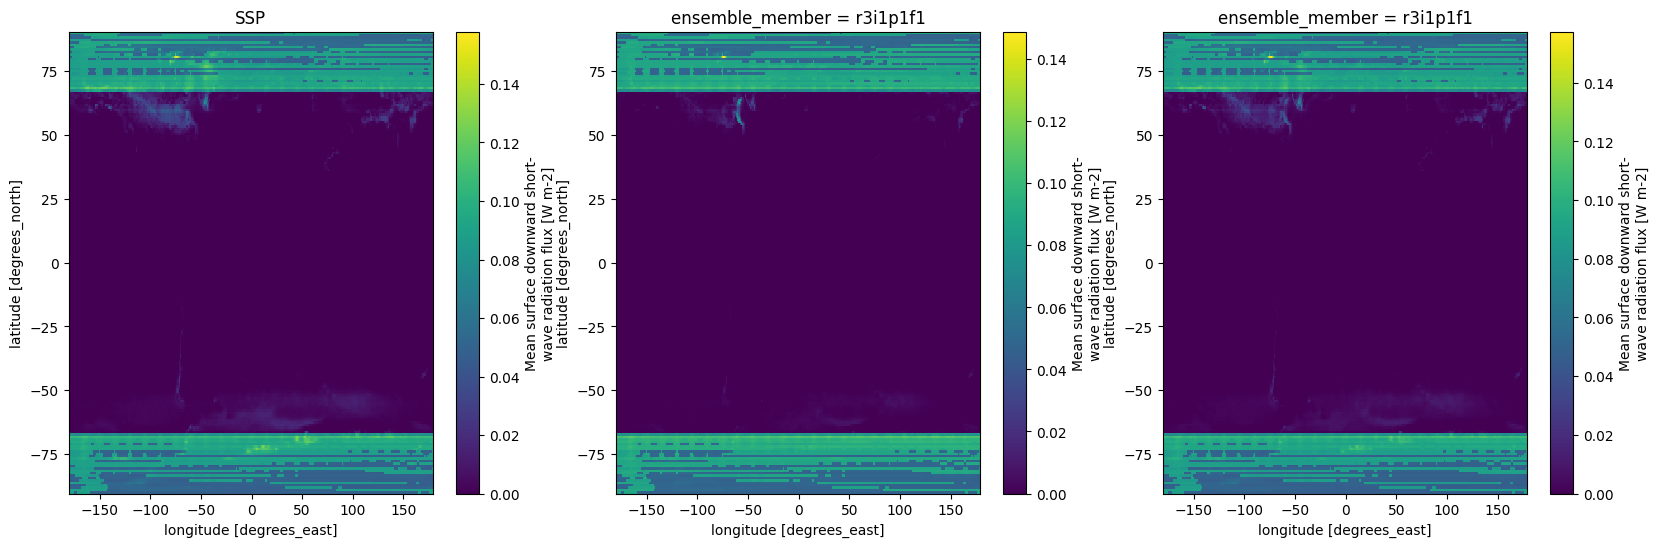

In [26]:
fig, axes=plt.subplots(ncols=3, figsize=(20,6))
frac_over_max_cd_hist.plot(ax=axes[0])
axes[0].set_title('Historical')
frac_over_max_cd_g6.plot(ax=axes[1])
axes[0].set_title('G6')
frac_over_max_cd_ssp.plot(ax=axes[2])
axes[0].set_title('SSP')

In [28]:
ilat=7
ilon=98
coarse_ssp_pt = coarse_debiased_ssp.sel(lon=ilon,lat=ilat,method='nearest')
coarse_g6_pt = coarse_debiased_g6.sel(lon=ilon,lat=ilat,method='nearest')
coarse_hist_pt = coarse_debiased_historical.sel(lon=ilon,lat=ilat,method='nearest')

raw_ssp_pt = raw_ssp.sel(lon=ilon,lat=ilat,method='nearest')
raw_hist_pt = raw_historical.sel(lon=ilon,lat=ilat,method='nearest')
raw_g6_pt = raw_g6.sel(lon=ilon,lat=ilat,method='nearest')
#coarse_obs_pt = coarse_obs.sel(lon=ilon,lat=ilat,method='nearest')

#threshold = max_value_strict.sel(lat=ilat, method="nearest").sel(dayofyear=coarse_ssp_pt["time.dayofyear"])

(array([0.00000000e+00, 3.22102686e-06, 0.00000000e+00, 6.44205373e-06,
        1.22399021e-04, 1.64272370e-04, 2.93113445e-04, 3.02776525e-04,
        6.50647426e-04, 6.73194614e-04, 8.82561361e-04, 9.56644978e-04,
        1.08870708e-03, 1.25297945e-03, 1.51388263e-03, 2.10655157e-03,
        2.62835792e-03, 2.88604007e-03, 3.68485473e-03, 4.94427624e-03,
        5.88481608e-03, 6.72550409e-03, 7.67248599e-03, 1.01108033e-02,
        9.65663854e-03, 9.75649037e-03, 8.77085615e-03, 8.57759454e-03,
        6.18437158e-03, 2.06789925e-03, 3.73639116e-04, 2.57682149e-05,
        6.44205373e-06, 2.25471880e-05, 3.22102686e-06, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
        110., 120., 130., 140., 150., 160., 170., 180., 190., 200., 210.,
        220., 230., 240., 250., 260., 270., 280., 290., 300., 310., 320.,
        330., 340., 350., 360., 370., 380., 390.]),
 <BarContainer objec

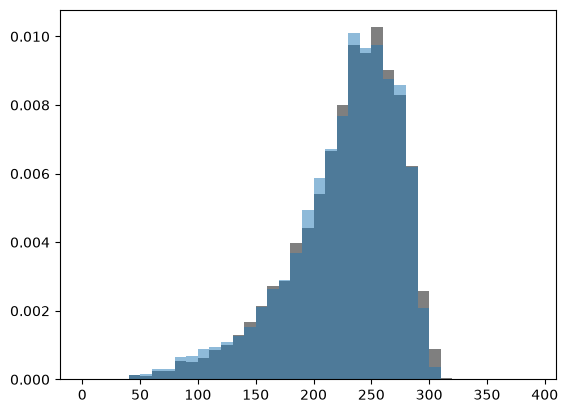

In [39]:
import numpy as np
plt.hist(coarse_hist_pt,alpha=0.5, color='k',bins=np.arange(0,400,10), density=True)
plt.hist(coarse_ssp_pt,alpha=0.5,bins=np.arange(0,400,10), density=True)

In [74]:
xslice=slice(10,50)
yslice=slice(25,65)

coarse_ssp_pt = coarse_debiased_ssp.sel(lon=xslice,lat=yslice).mean(dim=['lat','lon']).load()
coarse_g6_pt = coarse_debiased_g6.sel(lon=xslice,lat=yslice).mean(dim=['lat','lon']).load()
coarse_hist_pt = coarse_debiased_historical.sel(lon=xslice,lat=yslice).mean(dim=['lat','lon']).load()

raw_ssp_pt = raw_ssp.sel(lon=xslice,lat=yslice).mean(dim=['lat','lon']).load()
raw_hist_pt = raw_historical.sel(lon=xslice,lat=yslice).mean(dim=['lat','lon']).load()
raw_g6_pt = raw_g6.sel(lon=xslice,lat=yslice).mean(dim=['lat','lon']).load()
coarse_obs_pt = coarse_obs.sel(lon=xslice,lat=yslice).mean(dim=['lat','lon']).load()

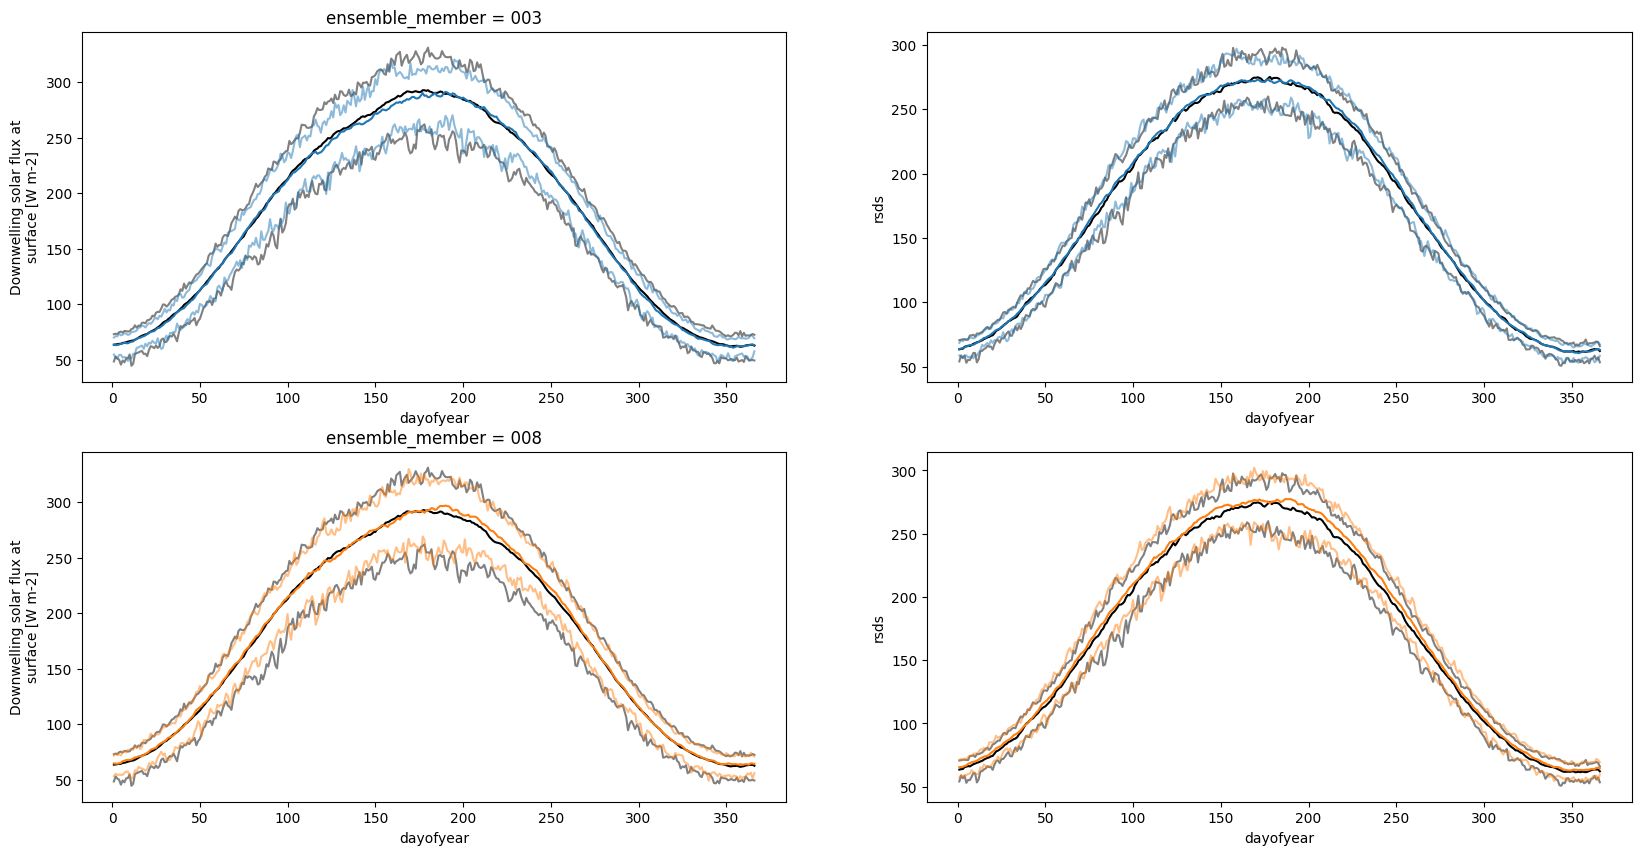

In [76]:
fig, axes=plt.subplots(ncols=2, nrows=2,figsize=(20,10))

raw_hist_pt[1:].groupby('time.dayofyear').mean(dim='time').plot(color='k',ax=axes[0,0])
raw_hist_pt[1:].groupby('time.dayofyear').max(dim='time').plot(color='gray',ax=axes[0,0])
raw_hist_pt[1:].groupby('time.dayofyear').min(dim='time').plot(color='gray',ax=axes[0,0])
raw_g6_pt[1:].groupby('time.dayofyear').mean(dim='time').plot(color='C0',ax=axes[0,0])
raw_g6_pt[1:].groupby('time.dayofyear').max(dim='time').plot(color='C0',alpha=0.5,ax=axes[0,0])
raw_g6_pt[1:].groupby('time.dayofyear').min(dim='time').plot(color='C0',alpha=0.5,ax=axes[0,0])

coarse_hist_pt[1:].groupby('time.dayofyear').mean(dim='time').plot(color='k',ax=axes[0,1])
coarse_hist_pt[1:].groupby('time.dayofyear').max(dim='time').plot(color='gray',ax=axes[0,1])
coarse_hist_pt[1:].groupby('time.dayofyear').min(dim='time').plot(color='gray',ax=axes[0,1])
coarse_g6_pt[1:].groupby('time.dayofyear').mean(dim='time').plot(color='C0',ax=axes[0,1])
coarse_g6_pt[1:].groupby('time.dayofyear').max(dim='time').plot(color='C0',alpha=0.5,ax=axes[0,1])
coarse_g6_pt[1:].groupby('time.dayofyear').min(dim='time').plot(color='C0',alpha=0.5,ax=axes[0,1])

raw_hist_pt[1:].groupby('time.dayofyear').mean(dim='time').plot(color='k',ax=axes[1,0])
raw_hist_pt[1:].groupby('time.dayofyear').max(dim='time').plot(color='gray',ax=axes[1,0])
raw_hist_pt[1:].groupby('time.dayofyear').min(dim='time').plot(color='gray',ax=axes[1,0])
raw_ssp_pt[1:].groupby('time.dayofyear').mean(dim='time').plot(color='C1',ax=axes[1,0])
raw_ssp_pt[1:].groupby('time.dayofyear').max(dim='time').plot(color='C1',alpha=0.5,ax=axes[1,0])
raw_ssp_pt[1:].groupby('time.dayofyear').min(dim='time').plot(color='C1',alpha=0.5,ax=axes[1,0])

coarse_hist_pt[1:].groupby('time.dayofyear').mean(dim='time').plot(color='k',ax=axes[1,1])
coarse_hist_pt[1:].groupby('time.dayofyear').max(dim='time').plot(color='gray',ax=axes[1,1])
coarse_hist_pt[1:].groupby('time.dayofyear').min(dim='time').plot(color='gray',ax=axes[1,1])
coarse_ssp_pt[1:].groupby('time.dayofyear').mean(dim='time').plot(color='C1',ax=axes[1,1])
coarse_ssp_pt[1:].groupby('time.dayofyear').max(dim='time').plot(color='C1',alpha=0.5,ax=axes[1,1])
coarse_ssp_pt[1:].groupby('time.dayofyear').min(dim='time').plot(color='C1',alpha=0.5,ax=axes[1,1])

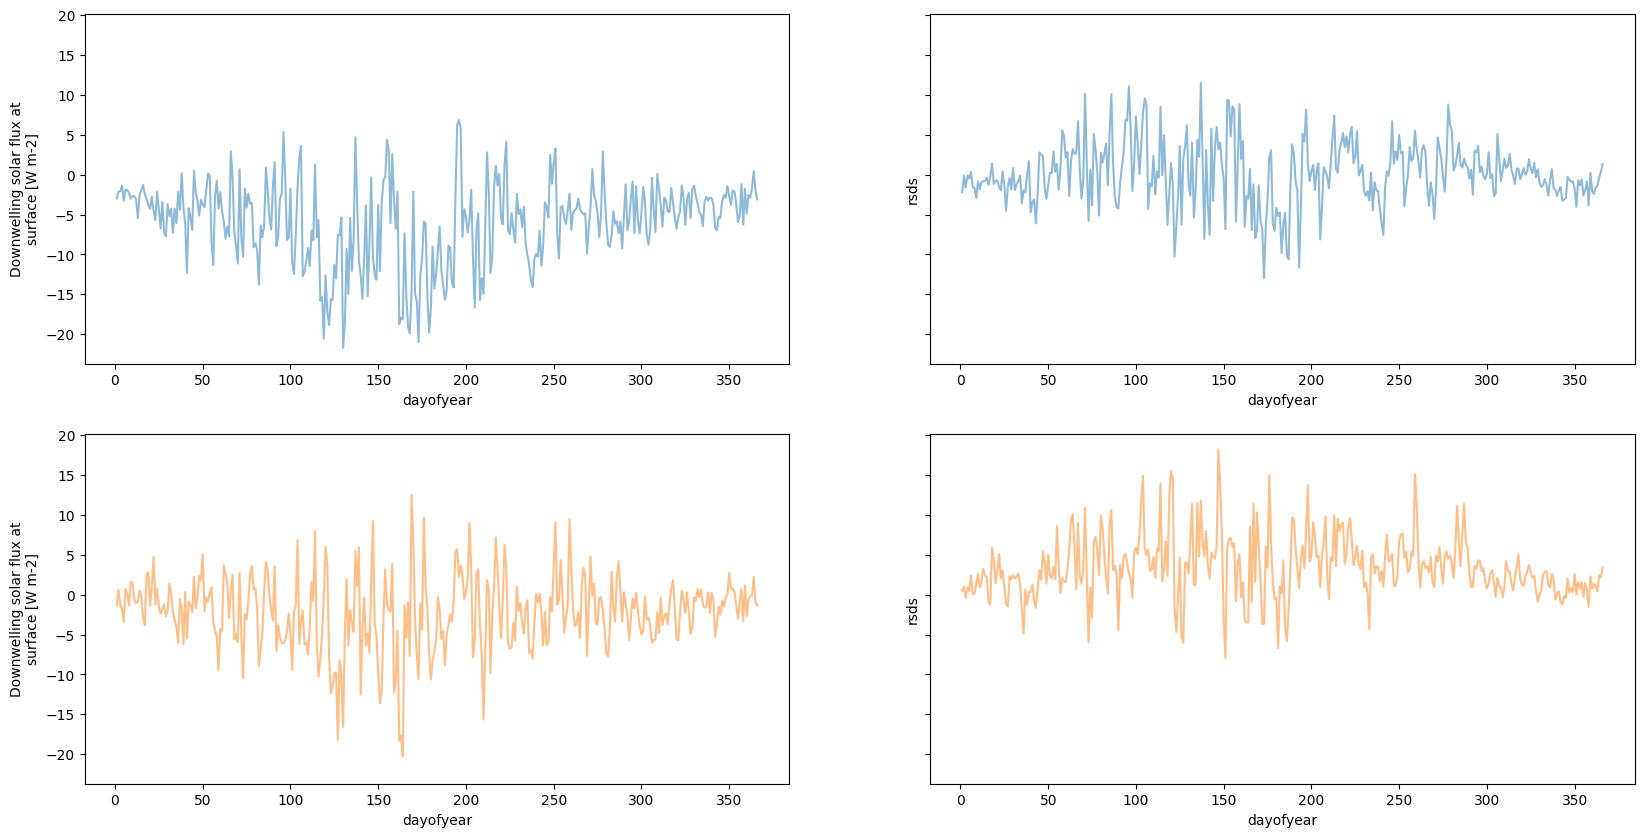

In [79]:
fig, axes=plt.subplots(ncols=2, nrows=2,figsize=(20,10), sharey=True)

(
 raw_g6_pt[1:].groupby('time.dayofyear').max(dim='time')-
raw_hist_pt[1:].groupby('time.dayofyear').max(dim='time')).plot(color='C0',alpha=0.5,ax=axes[0,0])


(coarse_g6_pt[1:].groupby('time.dayofyear').max(dim='time')-
 coarse_hist_pt[1:].groupby('time.dayofyear').max(dim='time')
).plot(color='C0',alpha=0.5,ax=axes[0,1])

(raw_ssp_pt[1:].groupby('time.dayofyear').max(dim='time')-
 raw_hist_pt[1:].groupby('time.dayofyear').max(dim='time')
).plot(color='C1',alpha=0.5,ax=axes[1,0])

(coarse_ssp_pt[1:].groupby('time.dayofyear').max(dim='time')-
 coarse_hist_pt[1:].groupby('time.dayofyear').max(dim='time')
).plot(color='C1',alpha=0.5,ax=axes[1,1])

In [9]:
ilat=-90
ilon=63.8
coarse_ssp_pt = coarse_debiased_ssp.sel(lon=ilon,lat=ilat,method='nearest')
coarse_g6_pt = coarse_debiased_g6.sel(lon=ilon,lat=ilat,method='nearest')
coarse_hist_pt = coarse_debiased_historical.sel(lon=ilon,lat=ilat,method='nearest')

ds_ssp_pt = ds_debiased_ssp.sel(lon=ilon,lat=ilat,method='nearest')
ds_g6_pt = ds_debiased_g6.sel(lon=ilon,lat=ilat,method='nearest')
ds_hist_pt = ds_debiased_historical.sel(lon=ilon,lat=ilat,method='nearest')

raw_ssp_pt = raw_ssp.sel(lon=ilon,lat=ilat,method='nearest')
raw_hist_pt = raw_historical.sel(lon=ilon,lat=ilat,method='nearest')
raw_g6_pt = raw_g6.sel(lon=ilon,lat=ilat,method='nearest')
#coarse_obs_pt = coarse_obs.sel(lon=ilon,lat=ilat,method='nearest')

#threshold = max_value_fine_obs.sel(lat=ilat, method="nearest").sel(dayofyear=coarse_ssp_pt["time.dayofyear"])

In [10]:
ssp_mean = raw_ssp.sel(time=slice("2040-01-01","2069-12-31")).mean(dim='time')
ssp_max = raw_ssp.sel(time=slice("2040-01-01","2069-12-31")).max(dim='time')

In [11]:
g6_mean = raw_g6.sel(time=slice("2040-01-01","2069-12-31")).mean(dim='time')
g6_max = raw_g6.sel(time=slice("2040-01-01","2069-12-31")).max(dim='time')

In [12]:
hist_mean = raw_historical.sel(time=slice("1978-01-01","2015-12-31")).mean(dim='time')
hist_meax = raw_historical.sel(time=slice("1978-01-01","2015-12-31")).max(dim='time')

(25.0, 65.0)

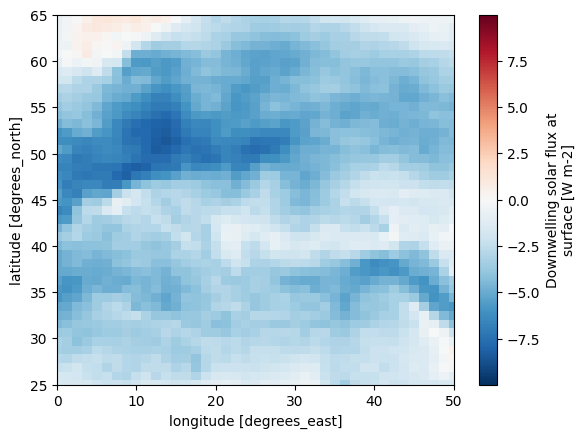

In [64]:
(g6_mean-ssp_mean).plot()


(25.0, 65.0)

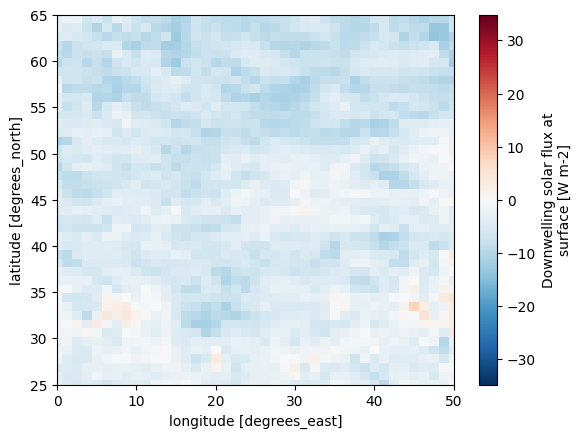

In [65]:
(g6_max-ssp_max).plot()
plt.xlim([0,50])
plt.ylim([25,65])

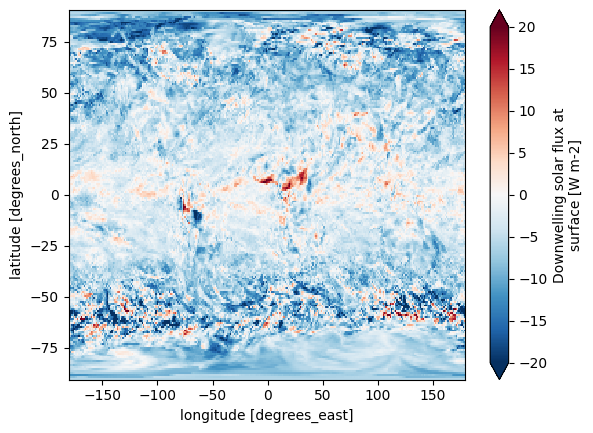

In [63]:
(g6_max-ssp_max).plot(vmax=20)

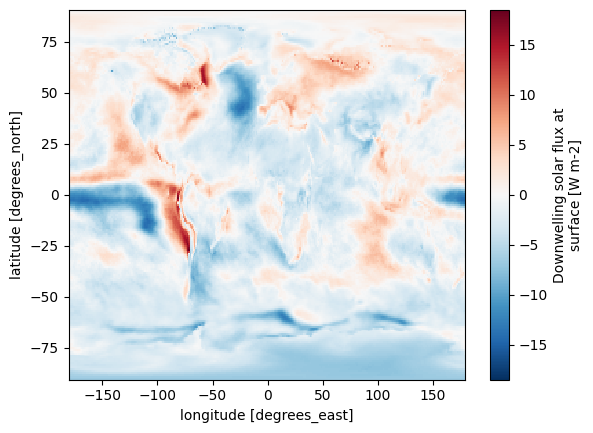

In [49]:
(g6_mean-hist_mean).plot()

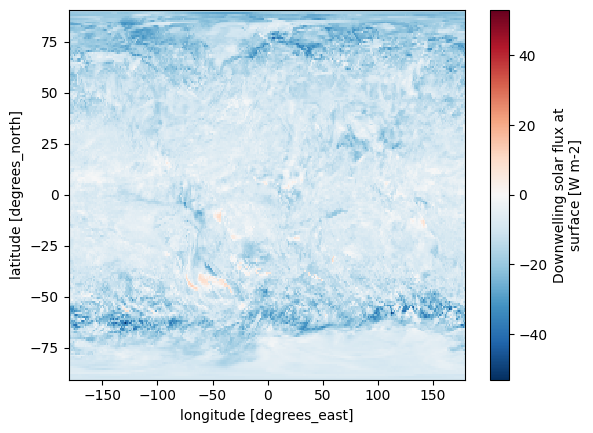

In [41]:
(raw_g6[1:,:,:].max(dim='time')-raw_historical[1:,:,:].max(dim='time')).plot()

In [24]:
lat=39.2
lon=14.8

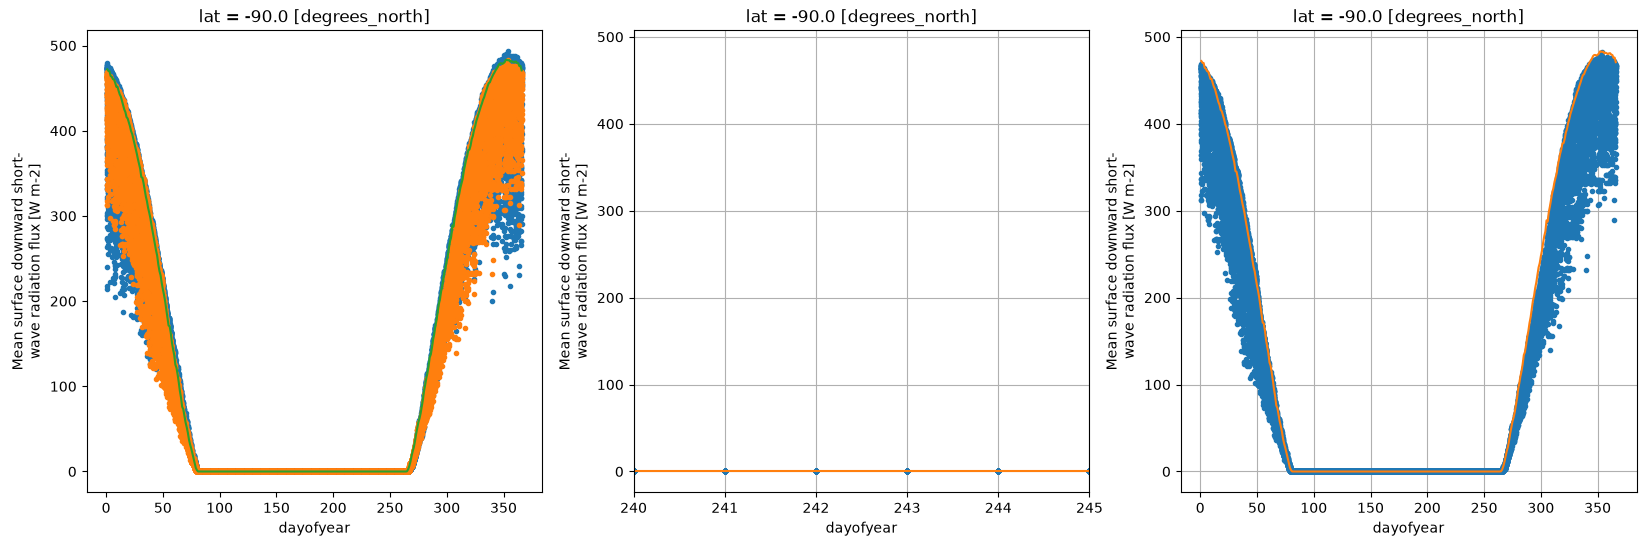

In [25]:
# KEY FIGURE TO REPRODUCE threshold = max_value_strict.sel(lat=ilat, method="nearest").sel(dayofyear=coarse_ssp_pt["time.dayofyear"])


fig, axes=plt.subplots(ncols=3, figsize=(20,6))
axes[0].plot(raw_ssp_pt['time.dayofyear'],raw_ssp_pt,'.')
axes[0].plot(ds_ssp_pt['time.dayofyear'],ds_ssp_pt,'.')
#axes[0].plot(ds_ssp_pt["time.dayofyear"], ds_ssp_pt.where(ds_ssp_pt > threshold), "o", fillstyle='none')
max_value_fine_obs.sel(lat=ilat, method='nearest').plot(ax=axes[0])

axes[1].plot(ds_ssp_pt['time.dayofyear'],ds_ssp_pt,'.')
#axes[1].plot(ds_ssp_pt["time.dayofyear"], ds_ssp_pt.where(ds_ssp_pt > threshold), "o", fillstyle='none')
axes[1].set_xlim([240,245])
#axes[1].set_ylim([50,250])
axes[1].grid()
max_value_fine_obs.sel(lat=ilat, method='nearest').plot(ax=axes[1])
axes[2].plot(ds_ssp_pt['time.dayofyear'],ds_ssp_pt,'.')
#axes[2].plot(ds_ssp_pt["time.dayofyear"], ds_ssp_pt.where(ds_ssp_pt > threshold), "o", fillstyle='none')
#axes[2].set_xlim([145,150])
#axes[2].set_ylim([350,450])
axes[2].grid()
max_value_fine_obs.sel(lat=ilat, method='nearest').plot(ax=axes[2])

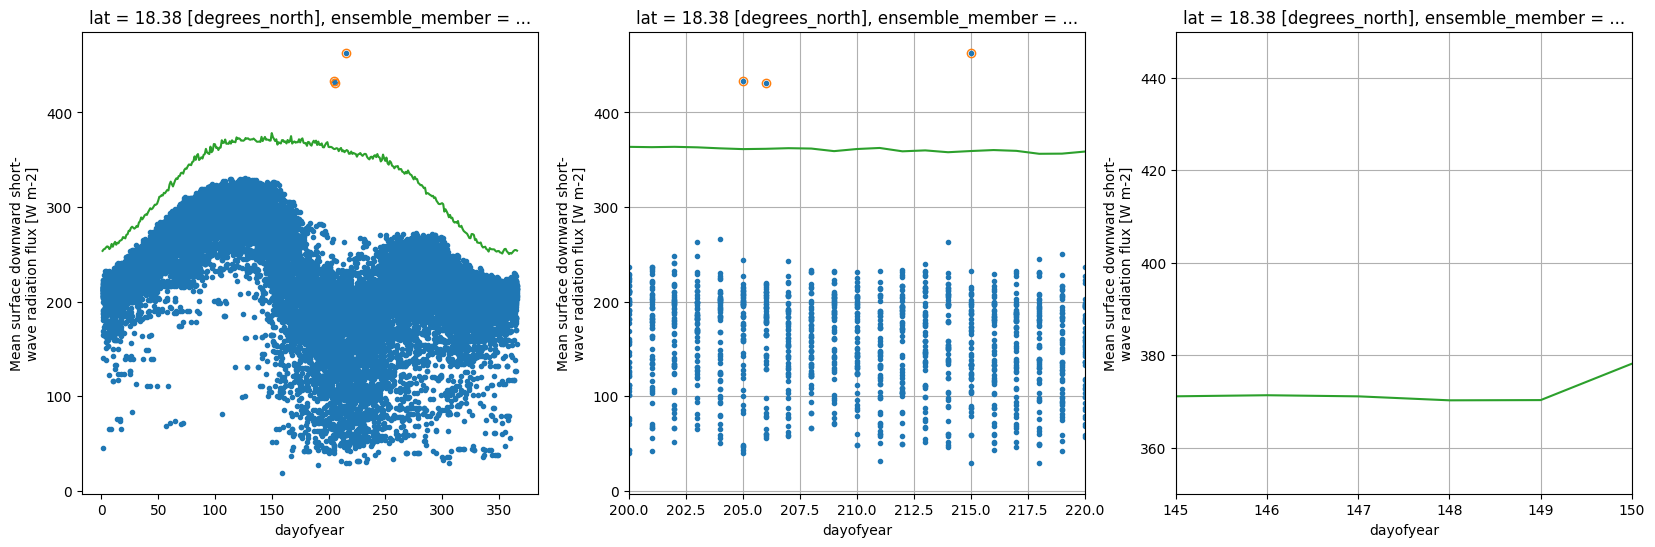

In [251]:
# KEY FIGURE TO REPRODUCE threshold = max_value_strict.sel(lat=ilat, method="nearest").sel(dayofyear=coarse_ssp_pt["time.dayofyear"])


fig, axes=plt.subplots(ncols=3, figsize=(20,6))
axes[0].plot(coarse_ssp_pt['time.dayofyear'],coarse_ssp_pt,'.')
axes[0].plot(coarse_ssp_pt["time.dayofyear"], coarse_ssp_pt.where(coarse_ssp_pt > threshold), "o", fillstyle='none')
max_value_strict.sel(lat=ilat, method='nearest').plot(ax=axes[0])

axes[1].plot(coarse_ssp_pt['time.dayofyear'],coarse_ssp_pt,'.')
axes[1].plot(coarse_ssp_pt["time.dayofyear"], coarse_ssp_pt.where(coarse_ssp_pt > threshold), "o", fillstyle='none')
axes[1].set_xlim([200,220])
#axes[1].set_ylim([50,250])
axes[1].grid()
max_value_strict.sel(lat=ilat, method='nearest').plot(ax=axes[1])
axes[2].plot(coarse_ssp_pt['time.dayofyear'],coarse_ssp_pt,'.')
axes[2].plot(coarse_ssp_pt["time.dayofyear"], coarse_ssp_pt.where(coarse_ssp_pt > threshold), "o", fillstyle='none')
axes[2].set_xlim([145,150])
axes[2].set_ylim([350,450])
axes[2].grid()
max_value_strict.sel(lat=ilat, method='nearest').plot(ax=axes[2])

(array([17627.,  1353.,  1290.,  1253.,  1221.,  1206.,  1372.,  1668.,
         1901.,  2155.]),
 array([6.10351562e-05, 4.85557632e+01, 9.71114655e+01, 1.45667175e+02,
        1.94222870e+02, 2.42778564e+02, 2.91334290e+02, 3.39889984e+02,
        3.88445679e+02, 4.37001373e+02, 4.85557098e+02]),
 <BarContainer object of 10 artists>)

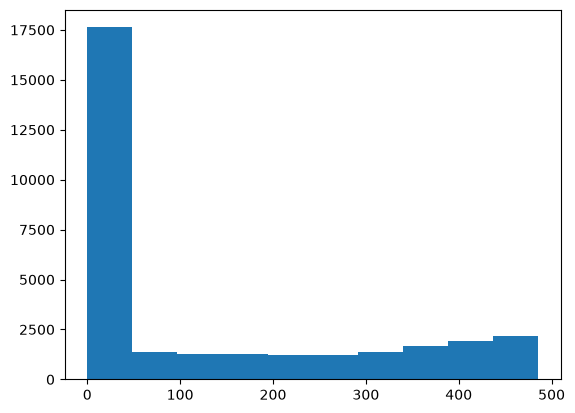

In [23]:
plt.hist(coarse_ssp_pt)

In [124]:
def da_windowed(da, doy=45):
    da_subset = da.where((da['time.dayofyear']>=doy-15), drop=True)
    da_subset = da_subset.where((da_subset['time.dayofyear']<=doy+15), drop=True)
    return da_subset

In [183]:
coarse_obs_pt_window = da_windowed(da=coarse_obs_pt, doy=45).load()
raw_hist_pt_window = da_windowed(da=raw_hist_pt, doy=45).load()
raw_ssp_pt_window = da_windowed(da=raw_ssp_pt, doy=45).load()

In [ ]:
print(np.nanmax(

(array([1.444e+03, 5.900e+01, 4.200e+01, 3.500e+01, 3.300e+01, 3.000e+01,
        2.600e+01, 2.600e+01, 5.000e+00, 4.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. , 3.3, 3.6,
        3.9, 4.2, 4.5, 4.8, 5.1, 5.4, 5.7, 6. , 6.3, 6.6, 6.9, 7.2, 7.5,
        7.8, 8.1, 8.4, 8.7, 9. , 9.3, 9.6, 9.9]),
 <BarContainer object of 33 artists>)

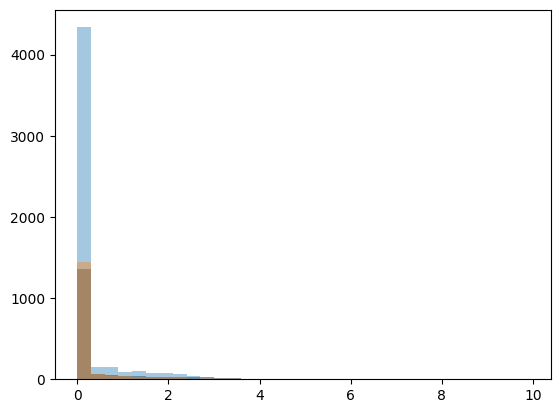

In [189]:
import numpy as np
bins=np.arange(0,10,0.3)
plt.hist(coarse_obs_pt_window, alpha=0.4, color='k', bins=bins)
plt.hist(raw_hist_pt_window, alpha=0.4, bins=bins)
plt.hist(raw_ssp_pt_window, alpha=0.4, bins=bins)

In [126]:
ilat_maxval=max_value_fine_obs.sel(lat=ilat,method='nearest').sel(dayofyear=doy)

In [127]:
raw_hist_pt_window = da_windowed(da=raw_hist_pt.sel(time=slice("1978-01-01","2015-01-01")), doy=doy).load()

In [128]:
raw_hist_pt_window.max(dim='time')

<xarray.DataArray 'rsds' ()> Size: 4B
array(304.62643, dtype=float32)
Coordinates:
    ensemble_member  <U8 32B 'r3i1p1f1'
    lat              float64 8B 7.068
    lon              float64 8B 97.5
Attributes:
    Sampling_Sequence:  rad_lwsw
    units:              W m-2
    long_name:          Downwelling solar flux at surface
    cell_methods:       time: mean

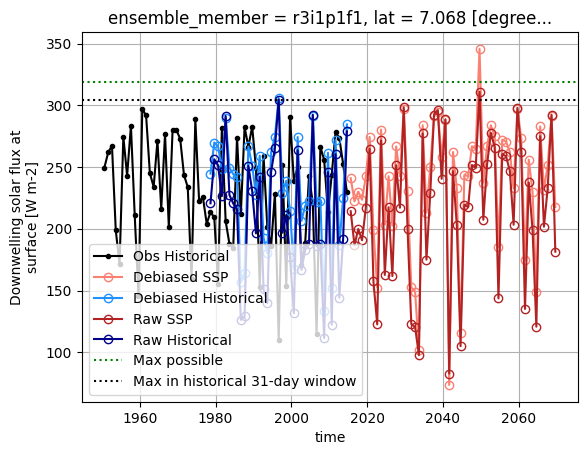

In [129]:
doy=243
coarse_obs_pt.where(coarse_obs_pt['time.dayofyear']==doy,drop=True).plot(label='Obs Historical', marker='.',color='k')
coarse_ssp_pt.where(coarse_ssp_pt['time.dayofyear']==doy,drop=True).plot(label='Debiased SSP', marker='o',fillstyle='none',color='salmon')#,linestyle='none')
coarse_hist_pt.where(coarse_hist_pt['time.dayofyear']==doy,drop=True).plot(label='Debiased Historical', marker='o',fillstyle='none',color='dodgerblue')#,linestyle='none')
raw_ssp_pt.where(raw_ssp_pt['time.dayofyear']==doy,drop=True).plot(label='Raw SSP', marker='o',fillstyle='none',color='firebrick')#,linestyle='none')
raw_hist_pt.where(raw_hist_pt['time.dayofyear']==doy,drop=True).sel(time=slice("1978-01-01","2015-01-01")).plot(label='Raw Historical', marker='o',color='darkblue',fillstyle='none')#,linestyle='none')
plt.axhline(y=ilat_maxval,linestyle=':',color='green', label='Max possible')
plt.axhline(y=304.62,linestyle=':',color='k', label='Max in historical 31-day window')
plt.legend()
plt.grid()

In [198]:
np.nanmax(coarse_ssp_pt.where(coarse_ssp_pt['time.dayofyear']==45,drop=True))

np.float32(0.35920864)